# COGS 108 - What Drives Popularity in Sports Nutrition Supplements?

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [  ] YES - make available
* [ X ] NO - keep private

## Link to video
https://youtu.be/vMGLJStaaPM

## Abstract

In this project, we investigate which product attributes are associated with the popularity of sports nutrition and bodybuilding supplements on Amazon. Because direct sales data are not available, we use the number of customer reviews as a proxy for product popularity and apply a log transformation to reduce the influence of extreme values. We analyze two datasets derived from Amazon: a product-level dataset containing attributes such as price, price per serving, ratings, brand, and category, and a review-level dataset capturing user engagement patterns.

Using exploratory data analysis techniques, including distribution analysis, scatterplots, category-level comparisons, and within-category analysis, we examine how these factors relate to consumer engagement. We find that price per serving is strongly right-skewed, indicating that most supplements are relatively inexpensive, while product ratings are highly concentrated near the upper end of the scale. Overall, price shows only a weak relationship with popularity. However, within specific categories such as whey protein, lower-priced products tend to receive more reviews. We also observe substantial differences across brands and product categories, suggesting that brand reputation and product type play an important role in shaping consumer engagement.

These findings suggest that supplement popularity on Amazon is influenced not only by product characteristics but also by category-level effects and user engagement dynamics, providing insight into how consumers interact with products in online marketplaces.

## Authors

Team list and credits:
- Scott Huang: Analysis, Conceptualization, Writing – review & editing
- Ye Teng: Background research, Visualization, Writing – review & editing
- Jingyun Xiong: Software, Video, Writing - original draft
- Fei Liang: Experiential Investigation, Project Administration, Writing - original draft
- Ruiqi Wang: Data curation, Methodology, Writing – review & editing

## Research Question

Which product attributes are associated with the popularity of sports nutrition/bodybuilding supplements on Amazon?


## Background and Prior Work


Dietary supplements are a growing part of the health and wellness market, and many consumers now buy products such as vitamins, protein powders, and probiotics through e-commerce platforms. Unlike prescription medications, dietary supplements are not strictly regulated before they are sold, which means consumers often rely on visible product information when making purchasing decisions.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) Because of this, attributes such as price, brand reputation, and especially online reviews play an important role in shaping supplement sales online.

Previous research on online shopping behavior has consistently shown that customer ratings and reviews have a strong influence on product sales. Chevalier and Mayzlin found that products with higher ratings and more positive reviews tend to sell better, particularly when consumers cannot easily evaluate product quality before purchase.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) This highlights how social proof becomes more important when buyers face uncertainty, which is often the case for health-related products like dietary supplements.

Beyond reviews, brand reputation also plays a key role in consumer decision-making. Prior research suggests that in online marketplaces with many similar products, consumers often rely on brand identity and reputation as signals of quality and reliability.<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) This project builds on prior work by examining how price, customer ratings, number of reviews, and brand are associated with actual dietary supplement sales on e-commerce platforms, using observed sales data rather than self-reported preferences.
1. <a name="cite_note-1"></a> [^](#cite_ref-1) U.S. Food & Drug Administration. Dietary Supplements.
https://www.fda.gov/food/dietary-supplements

2. <a name="cite_note-2"></a> [^](#cite_ref-2)Chevalier, J. A., & Mayzlin, D. (2006). The effect of word of mouth on sales: Online book reviews. Journal of Marketing Research, 43(3), 345–354. https://www.jstor.org/stable/30162409?seq=1 

3. <a name="cite_note-4"></a> [^](#cite_ref-4) Clemons, E. K., Gao, G. G., & Hitt, L. M. (2006). When online reviews meet hyperdifferentiation. Journal of Management Information Systems, 23(2), 149–171.  https://www.tandfonline.com/doi/abs/10.2753/MIS0742-1222230207


## Hypothesis


We hypothesize that review count, customer rating, price, and brand are associated with the popularity of sports nutrition/bodybuilding supplements on Amazon. Specifically, we expect products with more reviews and higher ratings to be more popular, because reviews act as a form of social proof and help reduce uncertainty for buyers. We also expect price-related measures (especially price per serving) to matter, since consumers may compare supplements based on perceived value. Among these variables, we expect review count to show the strongest relationship with popularity. Because we do not observe actual sales, we interpret our outcome as product popularity rather than direct sales.

## Data


### Data overview

**Unit of observation:** Amazon product listing (ideally one row per ASIN).  
**Primary dataset:** Kaggle “Amazon Products Sales Dataset 42K+ Items – 2025” (product-level snapshot).  
**Outcome (DV):** sales-performance proxy such as BSR / rank (lower rank = better sales).  
**Key predictors (IVs):** price, rating_avg, review_count, discount (if available), brand, category/subcategory.  
**Controls / derived variables (as needed):** category dummies, log(review_count), and optionally price-per-serving if servings/size can be parsed.  
**Supplementary dataset (optional):** Amazon Reviews’23 (McAuley Lab) to validate or reconstruct rating_avg/review_count and optionally derive review-text features.

**Why these data fit the project:** They directly contain (or allow construction of) variables describing product attributes and popularity/sales proxy, enabling us to test relationships between attributes (pricing, ratings, brand/category) and sales performance.

**Main constraints:** outcome is a proxy (not true sales), coverage may be incomplete, and some columns may be noisy or missing; we will report missingness, apply cleaning rules, and run robustness checks.


## Dataset #1 (Primary): Bodybuilding / sports nutrition supplement products

**Local file:** `bodybuilding_nutrition_products.csv`  
**Unit of observation:** one product (N = 840 rows, 14 columns)

**What it contains:**  
A product-level snapshot of supplement listings, including product name, brand, category, description, price metrics, and review-based signals (ratings and review counts).
product_name: the name of the supplement product

brand_name: the brand associated with the product

product_category: the product type/category (for example, whey protein, creatine, etc.)

price: listed product price

price_per_serving: cost per serving, which gives a better measure of value than price alone

overall_rating: average customer rating shown on the product listing

number_of_reviews: total number of reviews left by customers

average_flavor_rating: average rating for flavor, if available

number_of_flavors: number of flavor options

verified_buyer_number: number of verified buyers, if available

verified_buyer_rating: rating among verified buyers, if available

product_description: text description of the product

link: product URL

**Planned uses in this project:**
- Model relationships between **price/value** (`price`, `price_per_serving`) and **consumer response proxies** (`number_of_reviews`, `overall_rating`)
- Compare brands/categories controlling for price/value
- (Optional) extract simple text signals from `product_description` to classify supplement types (e.g., protein/creatine/vitamins) for subgroup analyses

**Known issues & cleaning plan (based on initial inspection):**
- Convert numeric fields to numeric types (some fields may be read as text)
- Handle missingness:
  - `product_category` has moderate missingness
  - flavor-related columns (e.g., `number_of_flavors`, `average_flavor_rating`) have substantial missingness
  - verified-buyer fields have notable missingness
- Deduplicate products if repeated entries exist
- Standardize brand/category strings (trim whitespace, case normalization)
- Transform `number_of_reviews` using `log1p` for modeling and visualization


In [1]:
import pandas as pd
import numpy as np

# Dataset #1 (Primary): supplement products (product-level)
raw_products_path = "bodybuilding_nutrition_products.csv"
products = pd.read_csv(raw_products_path)

print("Dataset #1 raw shape:", products.shape)
print(products.head(3))
print("Columns:", products.columns.tolist())

# Convert numeric columns to numeric (robust)
num_cols = [
    "price", "price_per_serving", "overall_rating", "number_of_reviews",
    "average_flavor_rating", "number_of_flavors",
    "verified_buyer_number", "verified_buyer_rating"
]
for c in num_cols:
    if c in products.columns:
        products[c] = pd.to_numeric(products[c], errors="coerce")

# Standardize key text fields
text_cols = ["product_name", "brand_name", "product_category", "top_flavor_rated", "link"]
for c in text_cols:
    if c in products.columns:
        products[c] = products[c].astype("string").str.strip()

# Drop exact duplicates
products = products.drop_duplicates()

# Derived feature for skewed counts
products["log_reviews"] = np.log1p(products["number_of_reviews"])

# Missingness table (useful for write-up)
missing_tbl = (
    products.isna().mean().mul(100).round(2).sort_values(ascending=False)
    .rename("missing_%").to_frame()
)
display(missing_tbl)

# Save processed Dataset #1
out_path = "data/02-processed/supp_products_clean.csv"
products.to_csv(out_path, index=False)
print("Saved Dataset #1 ->", out_path, "| shape:", products.shape)

Dataset #1 raw shape: (840, 14)
   average_flavor_rating              brand_name  \
0                    9.1      EVLUTION NUTRITION   
1                    8.4       Optimum Nutrition   
2                    8.3  JYM Supplement Science   

                                                link  number_of_flavors  \
0  https://sa.bodybuilding.com/store/evlution-nut...               29.0   
1  https://sa.bodybuilding.com/store/opt/whey.htm...               43.0   
2  https://sa.bodybuilding.com/store/jym/pre-jym....                9.0   

   number_of_reviews  overall_rating  price  price_per_serving  \
0             2575.0             9.4  19.99               0.67   
1             9926.0             9.3  57.99               0.79   
2             3947.0             9.1  48.99               1.63   

           product_category  \
0                     BCAAs   
1     Build Muscle Products   
2  Improve Workout Products   

                                 product_description             pro

,missing_%
number_of_flavors,54.64
top_flavor_rated,54.64
average_flavor_rating,53.93
verified_buyer_number,40.12
verified_buyer_rating,39.40
product_category,20.36
number_of_reviews,2.26
overall_rating,2.26
log_reviews,2.26
brand_name,0.00


Saved Dataset #1 -> data/02-processed/supp_products_clean.csv | shape: (840, 15)


## Dataset #2 (Supplementary): Amazon reviews (2023) — Kaggle subset

**Kaggle dataset id:** `wajahat1064/amazon-reviews-data-2023`  
**Unit of observation:** one review (review-level)

**What it contains (expected):**  
A reviews dataset with review-level fields such as star rating and review text (exact column names depend on the Kaggle files). This dataset is used as a complementary source to study review-language patterns and to validate trends observed in Dataset #1.
rating: the star rating given by the reviewer

text: the written review text

asin: product identifier used to link reviews to products

timestamp or other review metadata fields, if present

text_len: a derived variable we created to measure review text length

**How we will use it:**
- Replicate/validate high-level relationships (e.g., rating distributions, review-text signals) for supplements-related content
- (Optional) engineer review-text features (keyword counts or simple sentiment proxies) for supplements-related reviews

**How we will identify supplements-related records (planned approach):**
- If the Kaggle files include a category field, we will filter to health/supplement-related categories.
- If category is not available, we will use a transparent keyword-based filter on review text and/or product title (e.g., “vitamin”, “supplement”, “protein”, “creatine”, “omega-3”, “collagen”). We will report that this approach may introduce noise and treat it as a proxy filter.


In [2]:
import gzip, json
import pandas as pd

# Dataset #2: Amazon Reviews'23 (Health_and_Personal_Care) samples
reviews_path = "data/00-raw/reviews23/reviews_hpc_sample_50000.jsonl.gz"
meta_path    = "data/00-raw/reviews23/meta_hpc_sample_10000.jsonl.gz"

# load reviews
rows = []
with gzip.open(reviews_path, "rt", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))
df2_reviews = pd.DataFrame(rows)

# load meta
rows = []
with gzip.open(meta_path, "rt", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))
df2_meta = pd.DataFrame(rows)

print("Dataset #2 reviews shape:", df2_reviews.shape)
print("Dataset #2 meta shape:", df2_meta.shape)
display(df2_reviews.head(3))
display(df2_meta.head(3))

# minimal derived fields for EDA
df2_reviews["text_len"] = df2_reviews["text"].astype("string").str.len()

# save to processed (required by the checkpoint instructions)
df2_reviews.to_csv("data/02-processed/reviews23_hpc_sample.csv", index=False)
df2_meta.to_csv("data/02-processed/meta23_hpc_sample.csv", index=False)

print("Saved -> data/02-processed/reviews23_hpc_sample.csv")
print("Saved -> data/02-processed/meta23_hpc_sample.csv")

Dataset #2 reviews shape: (50000, 10)
Dataset #2 meta shape: (10000, 14)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Really loved the product but not available any...,Product was great. Went to re-order and found...,[],B00STSUPCS,B00STSUPCS,AGEX5WCJRSRMJBJ4YWNDTQFCQLQQ,1541625215401,0,True
1,5.0,Game Changer,This has been a game changer for me. Started ...,[],B00ZGKA4L4,B00ZGKA4L4,AFTVOHEOT4UHZET5AVM4S2AHSAYA,1488630376000,37,True
2,5.0,Fantastic,I have been suffering a couple months with hee...,[],B07KJVGNN5,B07KJVGNN5,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,1563966838905,0,True


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Health & Personal Care,CBT Adjustable Black Wooden Humbler,4.0,11,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Eurotique,[],"{'Brand': 'Eurotique', 'Style': 'Vibrator', 'I...",B07DGKWXSD,None
1,Health & Personal Care,Sukragraha One Head Rechargeable Foil Shaver S...,4.2,15,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],SUKRAGRAHA,[],"{'Brand': 'SUKRAGRAHA', 'Power Source': 'Batte...",B01ANIULES,None
2,Health & Personal Care,Thyroid Support Supplement Complex with Iodine...,4.2,58,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Herbtonics,[],"{'Brand': 'Herbtonics', 'Flavor': 'Black peppe...",B07C2CCM7Y,None


Saved -> data/02-processed/reviews23_hpc_sample.csv
Saved -> data/02-processed/meta23_hpc_sample.csv


## Results

#### EDA 1: Exploring Drivers of Supplement Popularity Using Review Volume (Dataset #1)

In this section, we explore the main product-level variables from our primary dataset to better understand how supplement characteristics relate to product popularity on Amazon. Because we do not have direct sales data, we use review count as a proxy for popularity, and we also use a log-transformed version of review count (log_reviews) to reduce skew from extremely popular products. These visualizations help us understand the distributions of key variables and identify patterns that may matter in later analyses.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df1 = pd.read_csv("data/02-processed/supp_products_clean.csv")
eda = df1.copy()
df1.shape, df1.columns

((840, 15),
 Index(['average_flavor_rating', 'brand_name', 'link', 'number_of_flavors',
        'number_of_reviews', 'overall_rating', 'price', 'price_per_serving',
        'product_category', 'product_description', 'product_name',
        'top_flavor_rated', 'verified_buyer_number', 'verified_buyer_rating',
        'log_reviews'],
       dtype='object'))

#### Distribution of Price per Serving Across Supplement Products

we first explore the distribution of price per serving across supplement products. Price per serving provides a more meaningful measure of value than total product price because supplements are often sold in different quantities. Understanding this distribution helps reveal how supplement products are priced in the market and whether pricing is concentrated within a narrow range or varies widely across products.

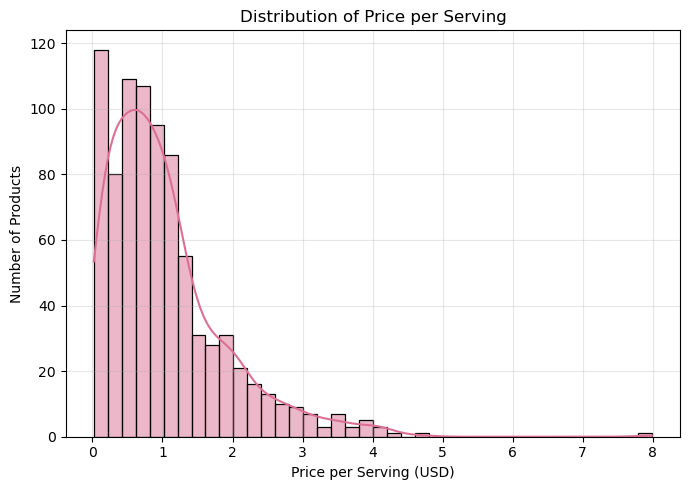

In [4]:
plt.figure(figsize=(7,5))

sns.histplot(
    df1["price_per_serving"].dropna(),
    bins=40,
    kde=True,
    color="palevioletred"
)

plt.xlabel("Price per Serving (USD)")
plt.ylabel("Number of Products")
plt.title("Distribution of Price per Serving")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The histogram shows that price per serving is strongly right-skewed. Most supplement products are concentrated at the lower end of the distribution, with many costing less than approximately $1–2 per serving. Only a relatively small number of products appear at higher price levels.

This pattern suggests that the supplement market is largely dominated by relatively inexpensive products, while higher-cost supplements represent a smaller portion of listings. A few high-price observations may act as outliers and pull the mean upward.

Because of this skewed distribution, the median and interquartile range may provide more informative summaries than the mean. In later analyses, grouping products into price ranges may also help reveal clearer patterns when comparing pricing with consumer response measures such as review counts and ratings.

#### Distribution of Product Ratings

Before examining how ratings relate to product popularity, we first explore the distribution of overall ratings across products. Understanding the distribution helps determine whether ratings vary enough to meaningfully distinguish products. If most products receive very similar ratings, the variable may have limited explanatory power in later analyses.


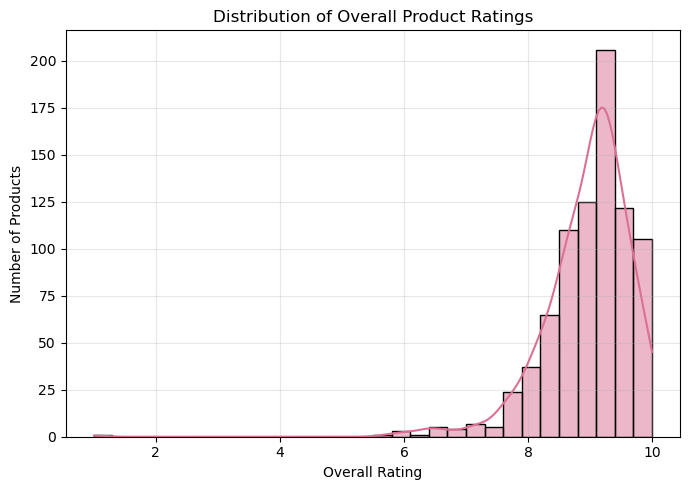

In [5]:
plt.figure(figsize=(7,5))

sns.histplot(
    df1["overall_rating"].dropna(),
    bins=30,
    kde=True,
    color="palevioletred"
)

plt.xlabel("Overall Rating")
plt.ylabel("Number of Products")
plt.title("Distribution of Overall Product Ratings")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The histogram shows that overall ratings are heavily concentrated near the upper end of the scale. Most products receive ratings between approximately 8 and 10, while relatively few products fall into the lower rating range. This indicates that the majority of supplements on Amazon are rated positively by customers.

Because ratings are clustered near the top of the scale, the variable exhibits a ceiling effect. This means that ratings may have limited variation across products, which reduces their ability to clearly distinguish highly popular products from less popular ones.


#### Distribution of Product Popularity (Log-Transformed Review Counts)

Before analyzing relationships between product attributes and popularity, we first examine the distribution of review counts. Because review counts are highly skewed, with a small number of products receiving extremely large numbers of reviews, we apply a log transformation to reduce the influence of extreme values. This allows us to better understand the overall spread of product popularity and ensures that later analyses are not dominated by a few highly popular products.

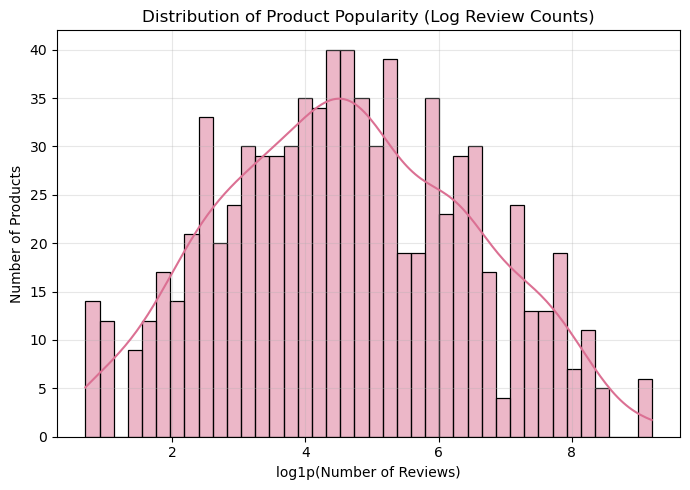

In [6]:
plt.figure(figsize=(7,5))

sns.histplot(
    df1["log_reviews"].dropna(),
    bins=40,
    kde=True,
    color="palevioletred"
)

plt.xlabel("log1p(Number of Reviews)")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Popularity (Log Review Counts)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The histogram shows the distribution of product popularity measured using the log-transformed number of reviews. Most products fall within the middle range of log review counts, while only a small number of products reach very high popularity levels. This indicates that the supplement market contains many moderately reviewed products and relatively few extremely popular ones.

The log transformation helps compress the upper tail of the distribution while preserving the ranking of products. Without this transformation, a few highly reviewed products would dominate the scale and make it difficult to analyze patterns among the majority of products. Using log_reviews therefore provides a more stable and interpretable measure of product popularity for subsequent analyses.

#### Price vs Product Popularity

Is the product price associated with product popularity? Since direct sales data are not available in Dataset #1, we use the number of reviews as a proxy for consumer demand. The review counts are transformed using log(1 + number_of_reviews) to reduce skew caused by extremely popular products. Visualizing price against this popularity proxy helps us see whether more expensive products tend to receive more consumer attention.

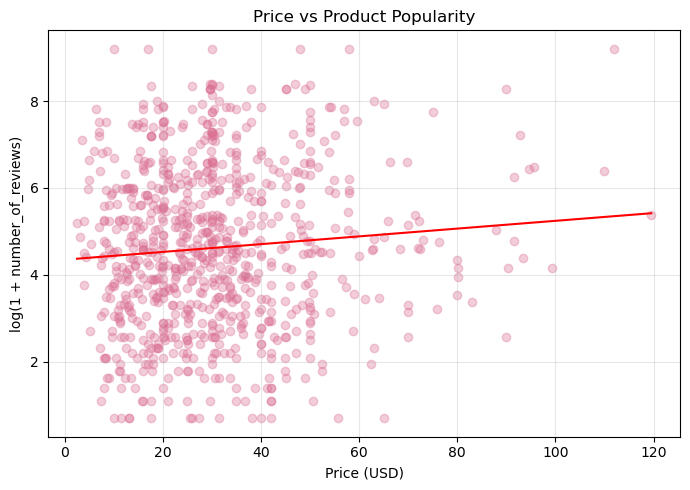

In [7]:
x = eda["price"].to_numpy()
y = eda["log_reviews"].to_numpy()

plt.figure(figsize=(7,5))

plt.scatter(x, y, alpha=0.35, color= "palevioletred")

plt.xlabel("Price (USD)")
plt.ylabel("log(1 + number_of_reviews)")
plt.title("Price vs Product Popularity")

plt.grid(True, alpha=0.3)

# Trend line
mask = np.isfinite(x) & np.isfinite(y)
if mask.sum() > 2:
    m, b = np.polyfit(x[mask], y[mask], 1)
    xs = np.linspace(x[mask].min(), x[mask].max(), 200)
    plt.plot(xs, m*xs + b, color= "red")

plt.tight_layout()
plt.show()

The scatterplot shows a weak positive relationship between product price and the popularity proxy (log-transformed review counts). The fitted trend line slopes slightly upward, suggesting that higher-priced products may sometimes receive more reviews. However, the points are widely dispersed across the plot, indicating that price alone does not strongly explain variation in popularity. Many lower-priced products also receive large numbers of reviews. This suggests that other factors, such as brand reputation, product category, marketing visibility, or product age likely play a more important role in determining consumer demand.

#### Relationship Between Price per Serving and Product Popularity

To understand whether product pricing influences consumer engagement, we examine the relationship between price per serving and product popularity. Because direct sales data is not available, we use the number of reviews as a proxy for popularity and apply a log transformation to reduce skew from extremely popular products.

The following scatter plot allows us to visually assess whether more expensive supplements tend to receive more or fewer reviews. Identifying this relationship helps determine whether price may be a potential factor associated with product popularity on Amazon.


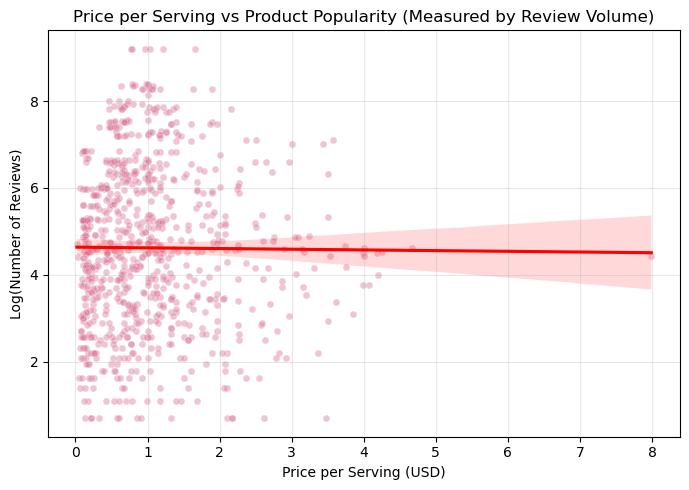

In [8]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df1,
    x="price_per_serving",
    y="log_reviews",
    alpha=0.4,
    s=25,
    color= "palevioletred"
)

sns.regplot(
    data=df1,
    x="price_per_serving",
    y="log_reviews",
    scatter=False,
    color="red"
)

plt.xlabel("Price per Serving (USD)")
plt.ylabel("Log(Number of Reviews)")
plt.title("Price per Serving vs Product Popularity (Measured by Review Volume)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The scatter plot examines the relationship between price per serving and product popularity, measured by the log-transformed number of reviews. Most products cluster within the lower price range, indicating that the majority of dietary supplements on Amazon are relatively inexpensive on a per-serving basis.

The fitted regression line is nearly flat, suggesting little to no strong linear relationship between price per serving and popularity. This indicates that price alone may not be a primary driver of consumer engagement. Other factors such as brand reputation, product category, and marketing visibility may play a more important role in influencing review volume.


#### Overall Rating vs Product Popularity

We created this plot to examine whether products with higher customer ratings tend to be more popular. Since direct sales data are not available, we use the number of reviews as a proxy for popularity. Review counts are log-transformed using log(1 + number_of_reviews) to reduce skew caused by extremely popular products. Visualizing overall rating against this popularity proxy helps us understand whether perceived product quality is associated with greater consumer engagement.

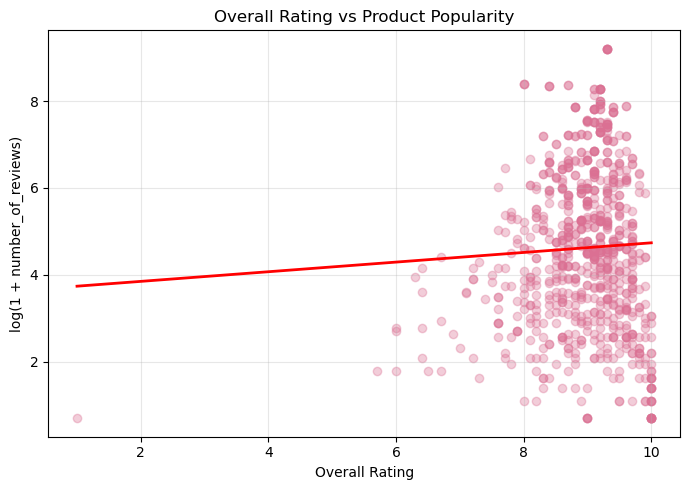

In [9]:
x = eda["overall_rating"].to_numpy()
y = eda["log_reviews"].to_numpy()

plt.figure(figsize=(7,5))

plt.scatter(x, y, color="palevioletred", alpha=0.35)

plt.xlabel("Overall Rating")
plt.ylabel("log(1 + number_of_reviews)")
plt.title("Overall Rating vs Product Popularity")

plt.grid(alpha=0.3)

mask = np.isfinite(x) & np.isfinite(y)
if mask.sum() > 2:
    m, b = np.polyfit(x[mask], y[mask], 1)
    xs = np.linspace(x[mask].min(), x[mask].max(), 200)
    plt.plot(xs, m*xs + b, color="red", linewidth=2)

plt.tight_layout()
plt.show()

This figure is a scatterplot where each dot represents one supplement product. The x-axis is the product's overall_rating, and the y-axis is log(1 + number_of_reviews), which we use as a review-based proxy for popularity/consumer demand. A linear trend line is included to summarize the overall relationship between rating and popularity.

This figure examines whether perceived quality (overall_rating) is associated with higher consumer engagement. The fitted line suggests a weak positive association: products with higher ratings tend to have slightly higher popularity on average. However, there is still substantial variation, meaning that products with similar ratings can have very different review counts, likely due to differences in brand reputation, category/type, pricing, or how long the product has been available. Because ratings and review counts are both derived from customer reviews and may be influenced by product age and exposure, we interpret this pattern as an association rather than evidence that higher ratings cause higher demand.

#### Top 10 Brands: Average Popularity (log reviews)

We created this plot to compare the average popularity of products across major supplement brands. Popularity is measured using the log-transformed number of reviews (log(1 + number_of_reviews)), which serves as a proxy for consumer demand. To make comparisons meaningful, we focus on the 10 brands with the most products in the dataset, ensuring that the averages are based on sufficient observations. This visualization helps identify whether certain brands consistently attract more consumer attention.

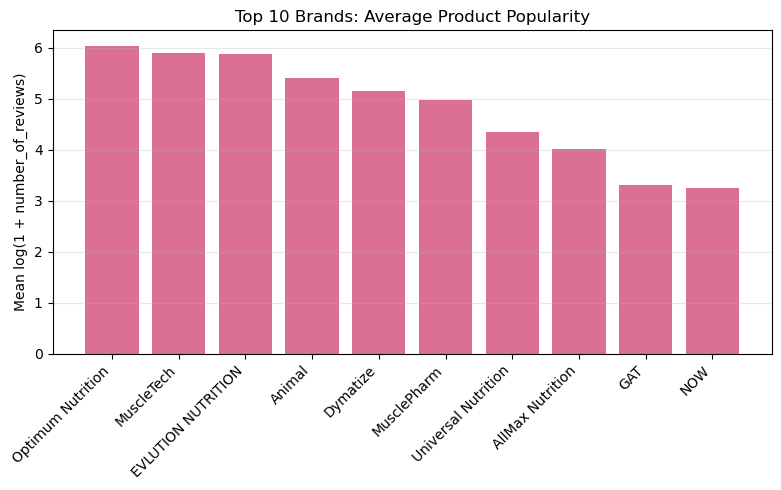

In [10]:
brand_counts = eda["brand_name"].value_counts()
top_brands = brand_counts.head(10).index

brand_summary = (
    eda[eda["brand_name"].isin(top_brands)]
    .groupby("brand_name")
    .agg(
        mean_log_reviews=("log_reviews", "mean"),
        n=("log_reviews", "size")
    )
    .sort_values("mean_log_reviews", ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(
    brand_summary.index.astype(str),
    brand_summary["mean_log_reviews"],
    color="palevioletred"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean log(1 + number_of_reviews)")
plt.title("Top 10 Brands: Average Product Popularity")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

This figure is a bar chart comparing brands on average popularity. We first identify the 10 most common brands in the dataset (by number of products) and then compute each brand's mean log(1 + number_of_reviews). The x-axis lists the brand names, and the y-axis shows the average popularity using log(1 + number_of_reviews) as a review-based proxy for consumer demand. The table printed below the chart reports the same summary values along with the number of products (n) for each brand.

This figure directly addresses whether popularity differs across brands, which is a key part of our research question. The results show clear variation: some brands have substantially higher average popularity than others, suggesting that brand reputation, distribution, marketing, or customer loyalty may be associated with consumer engagement. However, these comparisons are descriptive and do not control for other factors such as price, price per serving, or product category. In later modeling, we will include controls for these variables to test whether brand differences remain after accounting for differences in product mix and pricing.

#### Brand and category prevalence vs popularity

Before interpreting popularity patterns, we first check dataset coverage. Counting products per brand tells us which brands are most represented in our sample (prevalence). This is *not* a sales metric, but it helps us understand potential sampling/coverage bias and motivates later popularity analyses that use review-volume proxies.

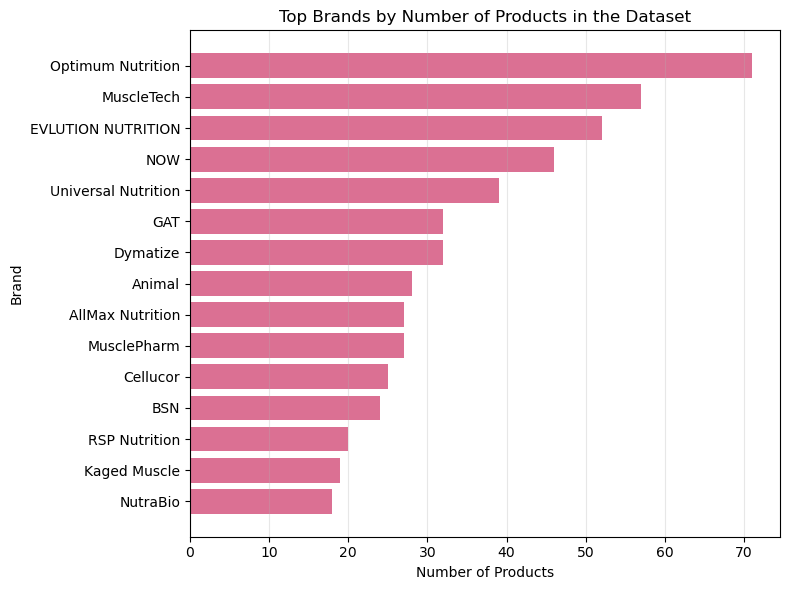

In [11]:
brand_counts = df1["brand_name"].value_counts().head(15)

plt.figure(figsize=(8,6))

plt.barh(
    brand_counts.index[::-1],
    brand_counts.values[::-1],
    color="palevioletred"
)

plt.xlabel("Number of Products")
plt.ylabel("Brand")
plt.title("Top Brands by Number of Products in the Dataset")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Optimum Nutrition appears most frequently in our dataset (71 products), followed by MuscleTech (57) and EVLUTION NUTRITION (52). This metric reflects **prevalence in the dataset**, not sales or popularity. Therefore, we should not interpret “more products listed” as “more popular.” In later EDA and modeling, we will use review-volume proxies (e.g., `log_reviews`) to measure popularity, and we may apply minimum-count filters (e.g., brands with at least 5 products) to avoid unstable comparisons for rare brands.

#### Category prevalence: which supplement categories appear most often?

Category prevalence tells us which supplement types dominate our product dataset. This matters because category can confound other relationships: different supplement types may have systematically different price-per-serving and review patterns. Understanding category coverage helps us interpret later popularity results and motivates category-controlled comparisons.

,count,percent
product_category,,
Unknown,171,20.36
Whey Protein,92,10.95
BCAAs,46,5.48
Creatine Monohydrate,40,4.76
Amino Acids,38,4.52
Whey Protein Isolate,34,4.05
Improve Workout Products,31,3.69
Build Muscle Products,30,3.57
Caffeine,28,3.33


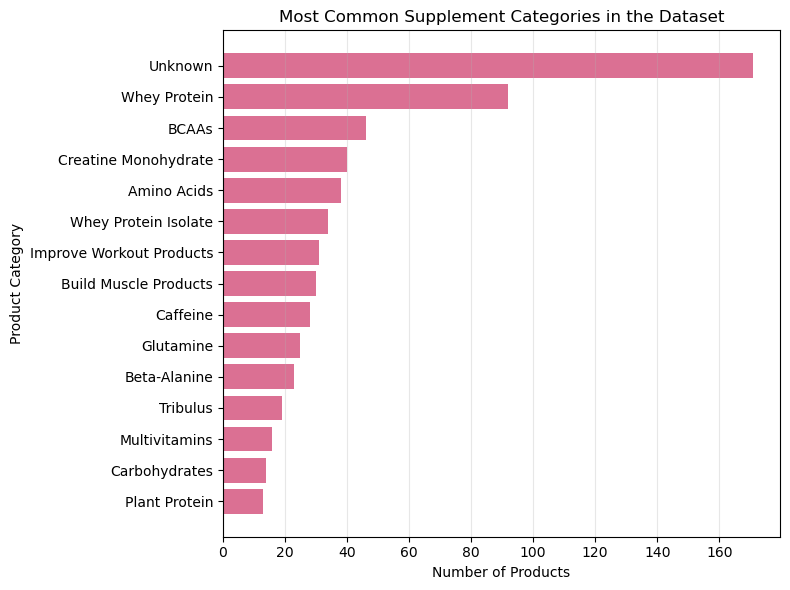

In [12]:
cat = df1["product_category"].astype("string").str.strip()
cat = cat.fillna("Unknown").replace("", "Unknown")

cat_counts = cat.value_counts()
cat_percent = (cat_counts / len(df1) * 100).round(2)

cat_summary = pd.DataFrame({
    "count": cat_counts,
    "percent": cat_percent
})

display(cat_summary.head(15))

top_cats = cat_counts.head(15)

plt.figure(figsize=(8,6))
plt.barh(top_cats.index[::-1], top_cats.values[::-1], color="palevioletred")

plt.xlabel("Number of Products")
plt.ylabel("Product Category")
plt.title("Most Common Supplement Categories in the Dataset")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

 Among labeled categories, **Whey Protein** is the most prevalent (92 products, **10.95%** of the dataset), followed by **BCAAs** (46, **5.48%**) and **Creatine Monohydrate** (40, **4.76%**). This indicates our product dataset is heavily represented by protein- and workout-related supplement types.  

The **Unknown** group (171 products, ~**20%**) reflects missing category labels rather than a true supplement type. Its large size suggests non-trivial missingness in `product_category`, which reduces our ability to do clean within-category comparisons for those products.  

Because category prevalence is uneven and category likely affects both price-per-serving and review volume, category acts as a potential **confounder**. Therefore, later popularity analyses should either (1) control for `product_category_clean` in models or (2) compare relationships (e.g., price vs `log_reviews`) within major categories rather than pooling all products together.

#### Within-Category Analysis: Price vs Popularity (Example: Whey Protein)

We created this plot to examine whether the relationship between price per serving and popularity still appears when we hold product category constant. Earlier analyses suggested that category may confound the overall relationship between pricing and popularity. By focusing only on whey protein products, we can better assess whether lower- or higher-priced products within the same category tend to receive more reviews.

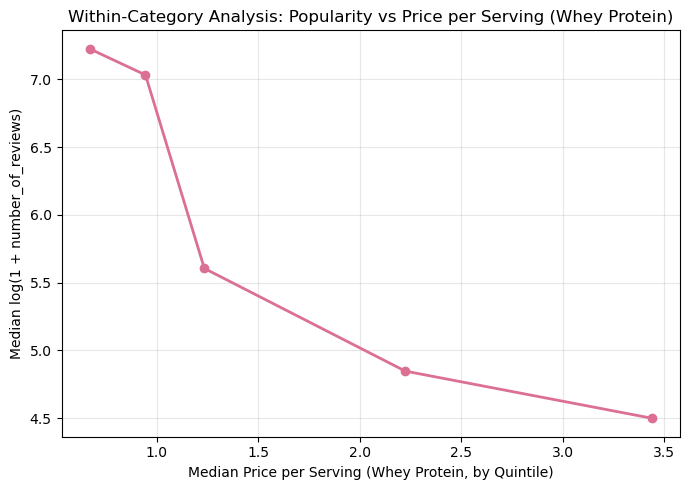

,pps_bin,median_price_per_serving,median_log_reviews,n_products
0,"(0.469, 0.808]",0.670,7.225481,19
1,"(0.808, 1.098]",0.945,7.032479,18
2,"(1.098, 1.74]",1.235,5.605369,18
3,"(1.74, 2.586]",2.225,4.847616,18
4,"(2.586, 4.2]",3.440,4.499810,19


In [13]:
if "log_reviews" not in df1.columns:
    df1["log_reviews"] = np.log1p(df1["number_of_reviews"])


df1["category_clean"] = (
    df1["product_category"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

target_category = "Whey Protein"

sub = df1.loc[
    df1["category_clean"] == target_category,
    ["price_per_serving", "log_reviews", "product_name"]
].dropna().copy()

sub["pps_bin"] = pd.qcut(
    sub["price_per_serving"],
    q=5,
    duplicates="drop"
)

trend = (
    sub.groupby("pps_bin", observed=False)
    .agg(
        median_price_per_serving=("price_per_serving", "median"),
        median_log_reviews=("log_reviews", "median"),
        n_products=("product_name", "count")
    )
    .reset_index()
)

plt.figure(figsize=(7, 5))
plt.plot(
    trend["median_price_per_serving"],
    trend["median_log_reviews"],
    marker="o",
    color="palevioletred",
    linewidth=2
)

plt.xlabel("Median Price per Serving (Whey Protein, by Quintile)")
plt.ylabel("Median log(1 + number_of_reviews)")
plt.title("Within-Category Analysis: Popularity vs Price per Serving (Whey Protein)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

trend

Within the **Whey Protein** category, we observe a clear negative association between price-per-serving and our popularity proxy. As the median price-per-serving increases across quintiles (≈0.67 → 3.44), the median `log_reviews` drops substantially (≈7.23 → 4.50). This indicates that, among whey protein products, lower cost-per-serving items tend to receive more reviews on average (higher typical popularity).  

Importantly, this pattern becomes much clearer only after restricting to a single category, suggesting that pooled analyses across categories were confounded by category differences. This motivates downstream modeling that controls for `product_category_clean` (and potentially brand) and explores within-category relationships rather than relying on overall trends.

#### Category popularity: which supplement categories are typically most popular?

Prevalence (how often a category appears) is not the same as popularity. To address our research question, we use `log_reviews = log1p(number_of_reviews)` as a popularity proxy and summarize it by category. Using the median reduces sensitivity to outliers (a few blockbuster products).

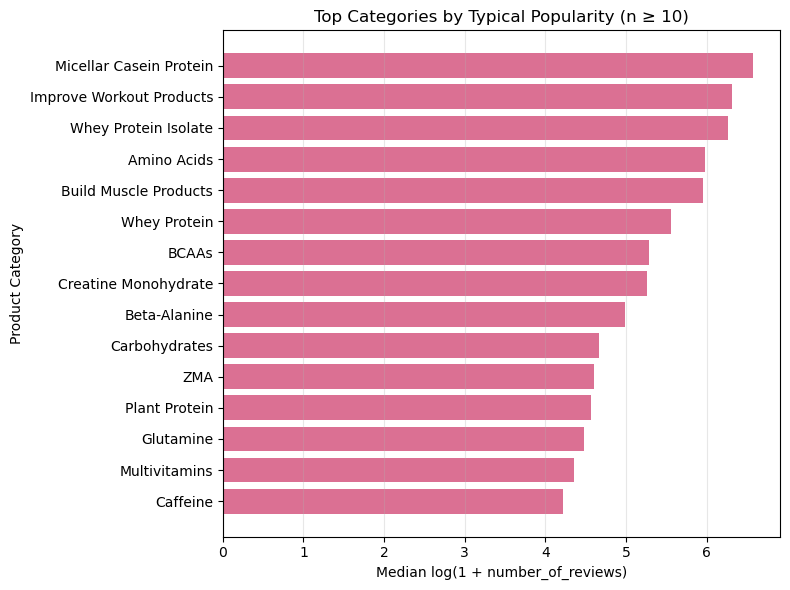

In [14]:
if "log_reviews" not in df1.columns:
    df1["log_reviews"] = np.log1p(df1["number_of_reviews"])

df1["product_category_clean"] = (
    df1["product_category"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

cat_pop = (
    df1.groupby("product_category_clean")
    .agg(
        median_log_reviews=("log_reviews", "median"),
        n_products=("product_name", "count")
    )
    .sort_values("median_log_reviews", ascending=False)
)

cat_pop_filtered = cat_pop[
    (cat_pop["n_products"] >= 10) &
    (cat_pop.index != "Unknown")
].head(15)

plt.figure(figsize=(8,6))
plt.barh(
    cat_pop_filtered.index[::-1],
    cat_pop_filtered["median_log_reviews"][::-1],
    color="palevioletred"
)

plt.xlabel("Median log(1 + number_of_reviews)")
plt.ylabel("Product Category")
plt.title("Top Categories by Typical Popularity (n ≥ 10)")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

This plot ranks supplement categories by the **median** of our popularity proxy (`log_reviews = log1p(number_of_reviews)`), restricted to categories with at least 10 products for stability. The most typically popular categories include **Micellar Casein Protein**, **Improve Workout Products**, and **Whey Protein Isolate**, followed by **Amino Acids** and **Build Muscle Products**. This suggests that protein- and performance-oriented supplement types tend to have higher typical review volume in our dataset.

Using the median reduces sensitivity to a small number of blockbuster products, since review counts are highly skewed. The clear spread across categories also indicates that **category is strongly associated with popularity**, so later analyses of price-per-serving or rating should control for `product_category_clean` (or compare within-category) to avoid confounding.

#### Category-Level Summary: Price and Popularity


The summary table below provides a category-level overview of pricing and popularity patterns across supplement types. For each of the most common product categories, we report the median price per serving, the median log-transformed review count, and the number of products in the dataset. Using medians helps reduce the influence of extreme values and provides a more robust representation of typical products within each category.

In [15]:
top_cats = (
    df1["product_category"]
    .fillna("Unknown")
    .value_counts()
    .head(10)
    .index
)

sub = df1[df1["product_category"].fillna("Unknown").isin(top_cats)].copy()

summary = (
    sub.assign(product_category=sub["product_category"].fillna("Unknown"))
       .groupby("product_category")
       .agg(
           median_price_per_serving=("price_per_serving", "median"),
           median_log_reviews=("log_reviews", "median"),
           n_products=("product_name", "count")
       )
       .sort_values("n_products", ascending=False)
)

summary

,median_price_per_serving,median_log_reviews,n_products
product_category,,,
Unknown,1.050,3.044522,171
Whey Protein,1.235,5.552689,92
BCAAs,0.580,5.280271,46
Creatine Monohydrate,0.155,5.257495,40
Amino Acids,0.615,5.982688,38
Whey Protein Isolate,1.485,6.257668,34
Improve Workout Products,1.000,6.309918,31
Build Muscle Products,1.040,5.955837,30
Caffeine,0.585,4.219508,28


The table shows that both pricing and popularity vary across supplement categories. Some categories, such as whey protein isolate and workout-related products, have relatively high median popularity levels, suggesting stronger consumer engagement. Other categories, such as caffeine or glutamine products, tend to have lower median review counts.

At the same time, median price per serving also differs across categories, reflecting different production costs, ingredient types, and product positioning. For example, creatine products generally have lower price-per-serving values compared with whey protein isolates.

These differences suggest that supplement categories represent distinct market segments with different pricing norms and consumer engagement patterns. As a result, comparing products across categories without accounting for these differences could lead to misleading conclusions. This motivates treating product_category as an important contextual variable in later analyses.

#### Product Popularity by Supplement Category


We created a set of boxplots to compare product popularity across supplement categories. Popularity is measured using the log-transformed number of reviews, which serves as a proxy for consumer demand. This plot helps us assess whether some supplement types tend to attract more consumer attention than others. Examining category differences is important because product category may confound other relationships, such as price or rating versus popularity.


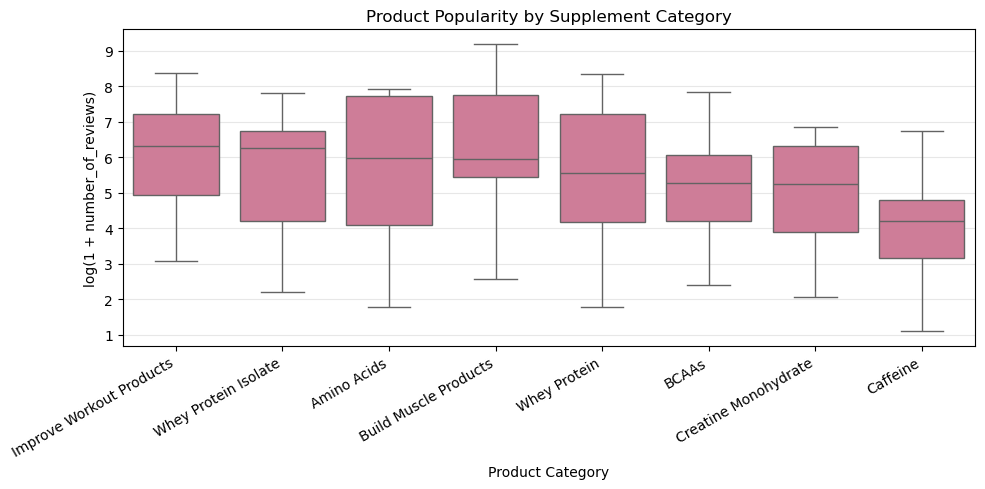

In [16]:
top_cats = eda["product_category"].value_counts().head(8).index
cat_df = eda[eda["product_category"].isin(top_cats)].copy()

cat_order = (
    cat_df.groupby("product_category")["log_reviews"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=cat_df,
    x="product_category",
    y="log_reviews",
    order=cat_order,
    color="palevioletred",
    showfliers=False
)

plt.xticks(rotation=30, ha="right")
plt.xlabel("Product Category")
plt.ylabel("log(1 + number_of_reviews)")
plt.title("Product Popularity by Supplement Category")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

This figure is a set of boxplots comparing popularity across the most common product categories in the dataset (top 8 by product count). For each category, the boxplot shows the distribution of log(1 + number_of_reviews), which we use as a review-based proxy for popularity/consumer demand. The center line is the median, the box represents the interquartile range (middle 50%), and the whiskers show the overall spread excluding extreme outliers (fliers are hidden for readability).

This figure addresses whether consumer engagement differs by supplement type, which is important because category can confound other relationships (e.g., price vs popularity). The boxplots show that categories have different typical popularity levels and different variability, suggesting that some supplement types tend to receive more reviews than others. This supports treating product_category as an important control variable in later analyses: without controlling for category, we might incorrectly attribute category-driven differences in popularity to price or rating. As with the other figures, we interpret these patterns as descriptive associations because review counts may also reflect product age and platform visibility.

#### Correlation Between Product Attributes and Popularity

To better understand how key product attributes relate to each other and to product popularity, we first examine a correlation matrix. This provides an overview of the relationships between variables such as price per serving, overall rating, and review counts before conducting more detailed comparisons.


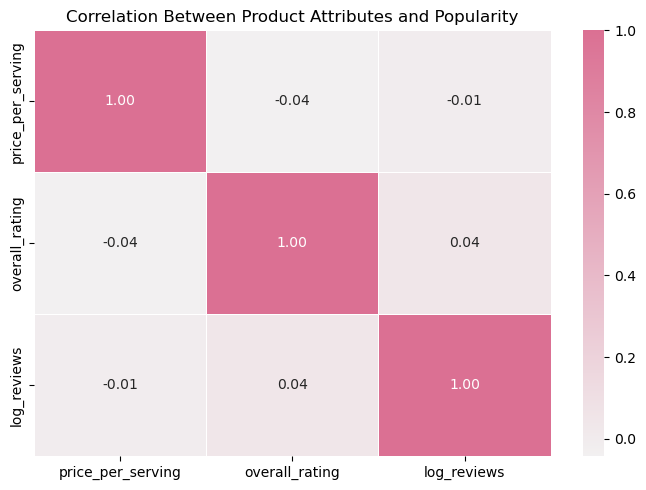

,price_per_serving,overall_rating,log_reviews
price_per_serving,1.000000,-0.042626,-0.007426
overall_rating,-0.042626,1.000000,0.043513
log_reviews,-0.007426,0.043513,1.000000


In [17]:
cols = [
    "price_per_serving",
    "overall_rating",
    "log_reviews"
]

corr = df1[cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(
    corr,
    annot=True,
    cmap=sns.light_palette("palevioletred", as_cmap=True),
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Between Product Attributes and Popularity")
plt.tight_layout()
plt.show()

corr = df1[["price_per_serving", "overall_rating", "log_reviews"]].corr()
corr

The correlation matrix shows very weak linear relationships between price per serving, overall rating, and popularity (measured by log-transformed review counts). All correlation values are close to zero, suggesting that no single variable has a strong linear association with product popularity in isolation.

One possible explanation is that ratings exhibit limited variation across products, as many supplements receive ratings close to 4–5 stars. This reduces the statistical correlation between ratings and popularity. Additionally, popularity on Amazon is likely influenced by multiple factors such as brand recognition, product category, and marketing exposure rather than a single attribute.


#### EDA 2: Review-Level Patterns in Customer Feedback

To complement the product-level dataset, we also examine the review-level dataset to better understand how customers leave feedback on Amazon. These plots do not directly answer our main research question, but they provide useful context about the behavior behind ratings and written reviews. In particular, they help us understand whether online reviews are balanced or if they show common platform biases.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df2_reviews = pd.read_csv("data/02-processed/reviews23_hpc_sample.csv")
df2_reviews.shape, df2_reviews.columns

((50000, 11),
 Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
        'timestamp', 'helpful_vote', 'verified_purchase', 'text_len'],
       dtype='object'))

In [19]:
df2_reviews.describe()

,rating,timestamp,helpful_vote,text_len
count,50000.000000,5.000000e+04,50000.000000,50000.00000
mean,4.001480,1.543010e+12,1.107120,187.50178
std,1.474232,8.345106e+10,8.785326,267.15567
min,1.000000,9.996505e+11,0.000000,0.00000
25%,3.000000,1.483302e+12,0.000000,45.00000
50%,5.000000,1.554894e+12,0.000000,107.00000
75%,5.000000,1.610054e+12,1.000000,227.00000
max,5.000000,1.693937e+12,1343.000000,8623.00000


In [20]:
df2_reviews.isna().sum(axis=0)
(df2_reviews.groupby('asin')['parent_asin'].nunique() !=1).sum()

0

In [21]:
(df2_reviews.groupby('asin')['parent_asin'].nunique() !=1).sum()

0

We examined the dataset shape, summary statistics, and missing values to understand the overall structure, data quality, and basic characteristics of the review data before performing deeper analysis. The dataset contains 50,000 reviews and 11 variables, including rating, review text, helpful votes, and product identifiers. This confirms that the dataset is sufficiently large for meaningful analysis.

From the summary statistics, we observe that the average rating is approximately 4.0, with a median of 5. This indicates that most reviews are highly positive, suggesting a positive bias in user ratings, which is common in online review platforms.

The missing value analysis shows that there are very few missing values (only a small number in the title and text columns), meaning the dataset is generally clean and does not require extensive preprocessing.

Finally, the check on asin and parent_asin confirms that each product maps consistently to a single parent product, indicating no inconsistencies in product hierarchy.

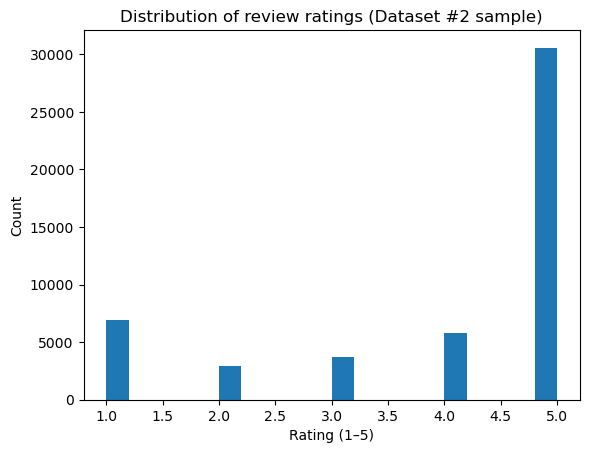

In [22]:
plt.figure()
df2_reviews["rating"].dropna().plot(kind="hist", bins=20)
plt.xlabel("Rating (1–5)")
plt.ylabel("Count")
plt.title("Distribution of review ratings (Dataset #2 sample)")
plt.show()

Review ratings are strongly concentrated at 5 stars. This suggests that the review data are not evenly distributed across the rating scale and may reflect positivity bias or selection bias. People who choose to leave reviews may be more likely to report very positive experiences, while moderate or negative experiences may be less represented. Because of this, average ratings should be interpreted carefully: a high rating may reflect real satisfaction, but it may also reflect the fact that online reviews tend to be skewed positive. This helps explain why rating variables may have limited variation in our analysis.

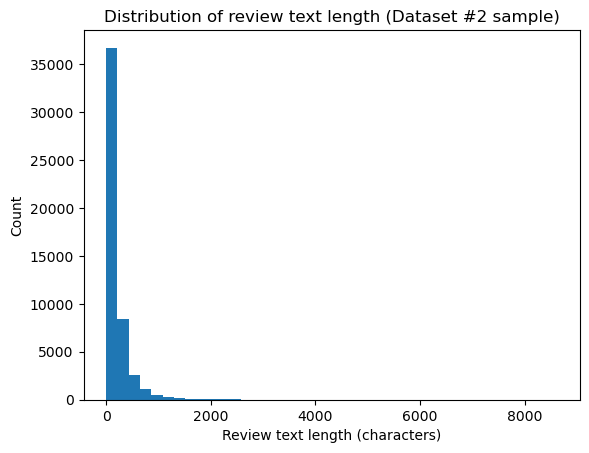

In [23]:
plt.figure()
df2_reviews["text_len"].dropna().plot(kind="hist", bins=40)
plt.xlabel("Review text length (characters)")
plt.ylabel("Count")
plt.title("Distribution of review text length (Dataset #2 sample)")
plt.show()

Review text length is also strongly right-skewed. Most reviews are fairly short, while a small number are much longer and more detailed. This suggests that written reviews vary a lot in depth and effort. If we later use any text-based features, longer reviews could disproportionately influence results unless those features are normalized. This plot shows that review text is uneven, so text-based measures should be interpreted with caution.

In [24]:
grouped = df2_reviews.groupby(['asin', 'parent_asin'])[['asin', 'parent_asin', 'rating', 'helpful_vote']].agg({'rating': 'mean', 'helpful_vote': 'sum'})
grouped['review_count'] = df2_reviews.groupby(['asin', 'parent_asin'])['rating'].sum('rating')
grouped.sort_values('helpful_vote', ascending=False)

,,rating,helpful_vote,review_count
asin,parent_asin,,,
B000LQI2S0,B07FTK5DWF,4.528846,1391,471.0
B01LZLSJ7B,B08MVCGBTV,3.761194,878,252.0
B000G2BESO,B08X9LB1WC,3.803448,731,1103.0
B0077L8YFI,B0077L8YFI,3.280788,562,666.0
B0872KHDY6,B0872KHDY6,4.384615,477,57.0
...,...,...,...,...
B06ZYHZMNB,B06ZYHZMNB,1.000000,0,1.0
B06ZYKNKP3,B06ZYKNKP3,5.000000,0,5.0
B06ZYP4CMR,B06ZYP4CMR,5.000000,0,10.0


In [25]:
df2_reviews[['helpful_vote', 'text_len']].sort_values('helpful_vote', ascending=False)

,helpful_vote,text_len
16960,1343,457
31225,414,2435
8479,400,437
31755,359,222
43852,260,971
...,...,...
19498,0,128
19502,0,200
19504,0,666
19506,0,152


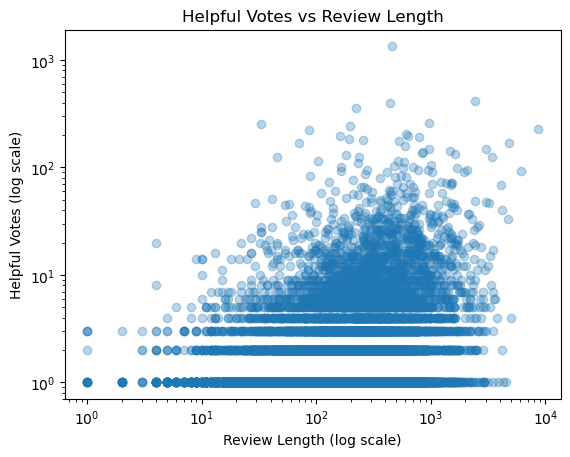

In [26]:
plt.figure()
plt.scatter(df2_reviews["text_len"], df2_reviews["helpful_vote"], alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Review Length (log scale)")
plt.ylabel("Helpful Votes (log scale)")
plt.title("Helpful Votes vs Review Length")
plt.show()

We grouped the data at the product level and examined the relationship between review length and helpful votes to understand what drives review visibility and engagement. Since helpful votes reflect how useful a review is perceived by other users, this analysis helps identify which review characteristics contribute to influence and, ultimately, product popularity.

From the product-level aggregation, we observe that products vary significantly in terms of average rating, total helpful votes, and number of reviews. Some products have a large number of reviews but relatively moderate helpful votes, while others have fewer reviews but disproportionately high helpful votes. This indicates that popularity is not solely determined by review volume, but also by how engaging or influential the reviews are.

Examining the top reviews sorted by helpful votes shows that highly voted reviews often have moderate to long text lengths, suggesting that more detailed reviews tend to attract more attention. However, this relationship is not perfectly consistent, as some long reviews receive few helpful votes, indicating that content quality—not just length—also plays an important role.

The scatter plot of helpful votes versus review length (on a log-log scale) further supports this observation. There is a general positive trend, where longer reviews are more likely to receive higher helpful votes. At the same time, the data is highly dispersed, with many short reviews receiving little to no engagement and a small number of reviews receiving very high helpful votes.

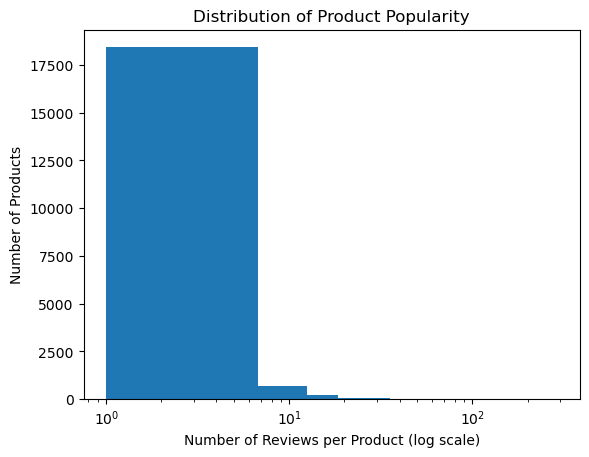

In [27]:
review_counts = df2_reviews["asin"].value_counts()

plt.figure()
plt.hist(review_counts, bins=50)
plt.xscale("log")
plt.xlabel("Number of Reviews per Product (log scale)")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Popularity")
plt.show()

We created this histogram to examine how product popularity is distributed across items, using the number of reviews per product (asin) as a proxy for popularity. This helps us understand whether popularity is evenly distributed or concentrated among a few products.

The histogram shows a highly right-skewed (long-tail) distribution of product popularity. Most products have very few reviews, while a small number of products have a significantly larger number of reviews.

Product popularity is not evenly distributed. Instead, it is concentrated among a small number of products, indicating that a few items dominate visibility and engagement in the market, while most products receive limited attention.

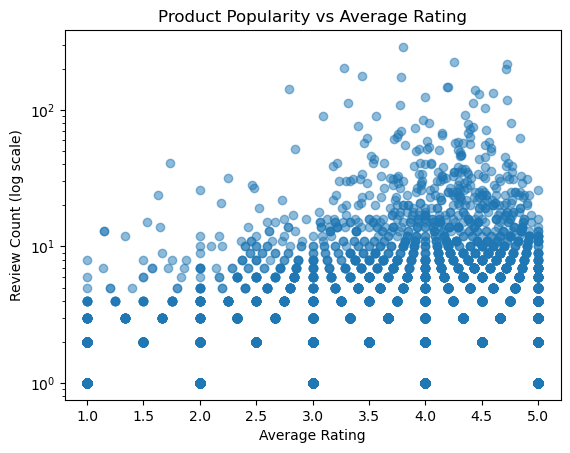

In [28]:
agg = df2_reviews.groupby("asin").agg({
    "rating": "mean",
    "asin": "count"
}).rename(columns={"asin": "review_count"})

plt.figure()
plt.scatter(agg["rating"], agg["review_count"], alpha=0.5)
plt.yscale("log")
plt.xlabel("Average Rating")
plt.ylabel("Review Count (log scale)")
plt.title("Product Popularity vs Average Rating")
plt.show()

We created this scatter plot to examine whether products with higher average ratings tend to be more popular, using review count as a proxy for popularity. This helps determine if rating is a strong factor associated with product popularity.

The scatter plot shows that most products have relatively high average ratings, with a large concentration between 3.5 and 5.0. This confirms the earlier observation that ratings are generally biased toward the higher end.

However, there is no strong or clear relationship between average rating and review count. Products with high ratings can have either very few or many reviews, and similarly, products with lower ratings are not consistently less popular.

Average rating does not appear to be a strong driver of product popularity. While most products are rated positively, popularity (as measured by review count) varies widely regardless of rating, indicating that other factors—such as visibility, engagement, or marketing—likely play a more significant role.

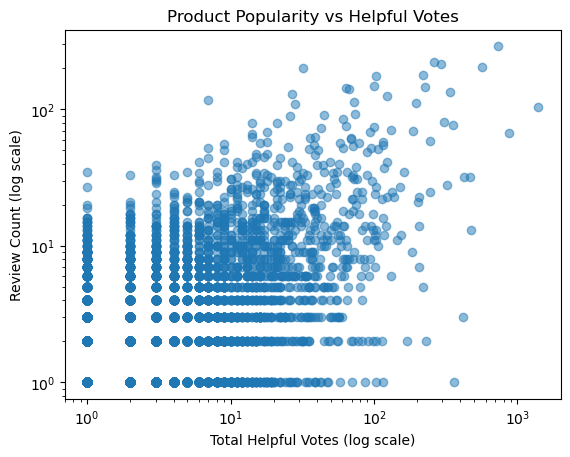

In [29]:
agg2 = df2_reviews.groupby("asin").agg({
    "helpful_vote": "sum",
    "asin": "count"
}).rename(columns={"asin": "review_count"})

plt.figure()
plt.scatter(agg2["helpful_vote"], agg2["review_count"], alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Total Helpful Votes (log scale)")
plt.ylabel("Review Count (log scale)")
plt.title("Product Popularity vs Helpful Votes")
plt.show()

We created this scatter plot to examine the relationship between total helpful votes and product popularity, where popularity is measured by the number of reviews per product. This helps us understand whether engagement (helpful votes) is associated with how popular a product becomes.

The scatter plot shows a clear positive relationship between total helpful votes and review count. Products that accumulate more helpful votes tend to also have a higher number of reviews, indicating that engagement and popularity are closely linked.

On the log-log scale, the data points form an upward trend, suggesting that as helpful votes increase, review counts generally increase as well. This implies that products with more influential or widely recognized reviews tend to attract more overall attention.

Helpful votes are strongly associated with product popularity. Products with more helpful and influential reviews tend to have higher review counts, suggesting that user engagement plays a key role in driving product visibility and popularity.

In [30]:
Unverified_purchase = df2_reviews[df2_reviews['verified_purchase'] == False]
Unverified_purchase.shape

(4913, 11)

In [31]:
df2_reviews['rating'].mean() - Unverified_purchase['rating'].mean()

-0.009307706085894374

In [32]:
(Unverified_purchase.groupby(['asin', 'parent_asin'])[['asin', 'parent_asin', 'rating', 'helpful_vote']]
 .agg({'rating': 'mean', 'helpful_vote': 'sum'})
 .sort_values('helpful_vote', ascending=False))

,,rating,helpful_vote
asin,parent_asin,,
B071F4Z16T,B0BLGM5PDZ,3.000000,424
B01LY4ZFR3,B01LY4ZFR3,1.000000,359
B00NMFUVZE,B00NMFUVZE,3.200000,261
B01DMA9R6C,B01DMA9R6C,5.000000,229
B0001ZWPI4,B0001ZWPI4,4.285714,177
...,...,...,...
B071KCLW8M,B071KCLW8M,5.000000,0
B071KWPLHR,B078KFMBTB,4.000000,0
B071LPGQ8X,B071LPGQ8X,5.000000,0


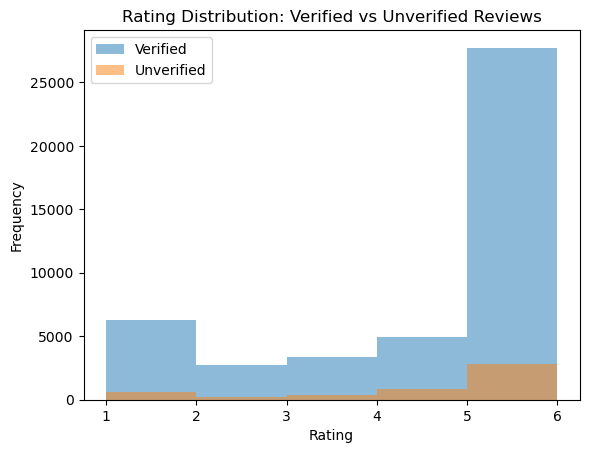

In [33]:
verified = df2_reviews[df2_reviews["verified_purchase"] == True]
unverified = df2_reviews[df2_reviews["verified_purchase"] == False]

plt.figure()
plt.hist(verified["rating"], bins=[1,2,3,4,5,6], alpha=0.5, label="Verified")
plt.hist(unverified["rating"], bins=[1,2,3,4,5,6], alpha=0.5, label="Unverified")

plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Rating Distribution: Verified vs Unverified Reviews")
plt.legend()
plt.show()

We separated reviews into verified and unverified purchases to examine whether these two groups differ in terms of rating behavior and influence. This helps determine whether verified purchase status is an important factor in understanding product popularity and review credibility.

The dataset contains 4,913 unverified reviews, which is a relatively small portion compared to the full dataset. When comparing average ratings, the difference between all reviews and unverified reviews is extremely small (approximately -0.009), indicating that unverified reviews have nearly identical rating behavior to the overall dataset.

The histogram comparing rating distributions further confirms this observation. Both verified and unverified reviews are heavily concentrated at higher ratings (especially 4 and 5 stars), showing a very similar distribution pattern. This suggests that verified purchase status does not significantly impact how users rate products.

However, the product-level aggregation of unverified reviews reveals that some products receive substantial helpful votes from unverified reviews, even when their average ratings vary. This indicates that unverified reviews can still contribute meaningfully to review visibility and engagement.

Verified and unverified reviews exhibit very similar rating patterns, suggesting that rating alone is not influenced by purchase verification. However, unverified reviews can still accumulate helpful votes and contribute to engagement, meaning they may still play a role in shaping product visibility and perceived popularity.

Overall, these EDA results suggest that review-based measures provide the clearest signal of product popularity, while price and ratings may still matter but likely operate in more complex ways. The plots also show that category differences and skewed distributions are important features of the data, so later analyses should account for these patterns rather than relying only on simple overall averages.

## Modeling

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = df1.copy()

In [42]:
if "log_reviews" not in df.columns:
    df["log_reviews"] = np.log1p(df["number_of_reviews"])

df = df.dropna(subset=["log_reviews"])
y = df["log_reviews"]

In [43]:
drop_cols = [
    "log_reviews",          # target
    "number_of_reviews",    # raw popularity target
    "link",                 # not meaningful for modeling
    "product_name",         # likely too specific / high-cardinality text
    "product_description"   # text field, not using in this pipeline
]

X = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [44]:
numeric_features = [
    "price",
    "price_per_serving",
    "number_of_flavors",
    "average_flavor_rating",
    "overall_rating",
    "verified_buyer_number",
    "verified_buyer_rating"
]

categorical_features = [
    "brand_name",
    "product_category",
    "top_flavor_rated"
]

numeric_features = [col for col in numeric_features if col in X.columns]
categorical_features = [col for col in categorical_features if col in X.columns]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
log_transform_features = [
    "price",
    "price_per_serving",
    "verified_buyer_number",
    "number_of_flavors"
]

log_transform_features = [col for col in log_transform_features if col in numeric_features]
regular_numeric_features = [col for col in numeric_features if col not in log_transform_features]

In [47]:
log_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("log_num", log_numeric_pipeline, log_transform_features),
    ("num", numeric_pipeline, regular_numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [48]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_preds = linear_model.predict(X_test)

In [49]:
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))
linear_r2 = r2_score(y_test, linear_preds)

print("Linear Regression Results")
print("RMSE:", linear_rmse)
print("R^2:", linear_r2)

Linear Regression Results
RMSE: 1.2657139488328062
R^2: 0.5278401432365669


First, we cleaned and prepared the data for modeling. We handled missing values by removing rows with missing target values and applying imputation to feature columns where necessary. We also transformed the target variable using a log transformation to reduce skewness in the number of reviews. Categorical variables such as brand name and product category were converted into numerical form using one-hot encoding, while numerical features were scaled using standardization to ensure they were on comparable ranges.

After preprocessing, we built a machine learning pipeline to streamline the workflow. The pipeline combined preprocessing steps (imputation, encoding, and scaling) with a linear regression model, ensuring that all transformations were applied consistently during training and testing. We then split the dataset into training and testing sets to evaluate the model’s performance on unseen data.

Finally, we trained the model and evaluated it using metrics such as R² and RMSE. The results showed that the model could explain a moderate portion of the variation in product popularity, providing a useful baseline. While the model captured meaningful relationships in the data, the evaluation also suggested that additional features or more complex models could further improve performance.

### Modeling Results

We used a linear regression model as a baseline approach to understand how different product attributes (such as price, ratings, and brand) are associated with product popularity, measured by the log-transformed number of reviews.

The model achieved an R² of approximately 0.528, meaning that about 52.8% of the variation in product popularity can be explained by the features included in the model. This indicates a moderate level of explanatory power, suggesting that the selected product attributes do capture meaningful patterns related to popularity.

The RMSE is approximately 1.27, which represents the average prediction error in terms of the log-transformed number of reviews. While this error is not negligible, it is reasonable given the inherent variability and skewness in product popularity.

Overall, the results suggest that product attributes such as price, ratings, and categorical features do have a measurable impact on popularity, but they do not fully explain it. There are likely additional factors—such as marketing, brand reputation beyond the dataset, or external visibility—that are not captured in the model.

The linear regression model provides a useful baseline and shows that product attributes explain a substantial portion of popularity, but the moderate R² indicates that popularity is influenced by additional factors beyond the features included in the dataset.

## Ethics

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> Our data will be reviews and ratings on the platforms, which are publicly available. We are not dealing with individual human subjects and asking for their consent. When they submitted the review, they understood that their reviews would be publicly available. So informed consent is not neccessary in this project. 

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> There are some bias that could be introduced in the data collection process. Products with more sales are likely to get more reviews. People are more likely to leave a review if their experience if really positive/negative. There could even be fake reivews from the seller trying to boost sales. We will try to find a way of normalizing reviews and minimize the bias mentioned above. 

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> We will collect all the data anonymously and neglect all the PII (e.g. account name, email). We will also only collect the reviews and rating of the product and not use any other irrelevant information.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

> We will ensure the results don't favor any groups over others unfairly. It will be clearly stated that this project studies the nature of consumer behaviors based on ratings, reviews, and sales of dietary supplements rather than their actual medical effectiveness.


### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

> Since the data would be public available already and we are not doing any new data collection ourselves, there will not be any measures used to protect or secure data.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

> There are no data directly collected from any individual in the data collection process, and there will not be any personal information included.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

> There is currently no plan to delete the local copy of the data we obtain. However, it is unlikely that we ever use the data for any other purposes in the future. It is possible that we will have a data retention plan after we have completed the project and the data is no longer needed.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

> Due to the nature of this project, the analysis is more likely to reflect trends in customers' purchasing behaviors rather than the true health benefits of the supplements. We will clearly state the the limitations in the analysis in the report so the users are aware.
 
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> Besides the bias already mentioned in the data collection part, there are some other potential bias in the dataset. There might be a significant difference in sales and rating/reviews across different categories of supplements. There could also be temporal bias, where older products recieve more reviews over time. We will address these bias by comparing supplements by category and normalize the effetcs of temporal bias.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> Our visualizations and summary statistics will be presented in the sole purpose of helping the readers understand the data more intuitively and represent the underlying data. The representations will be closely related to the focus of the projects and will not contain any irrelevant or distracting information.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

> We will ensure that no data with PII will be used in the project. We do not need any PII for the purpose of the project so any data related to PII would be removed in the data cleaning process.

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> The process of generating the analysis will be well documented throughout the project and presented in our final report. It will be documented step by step in detail such that the analysis is reproducible if we ever need to conduct the same analysis again. 

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

> We ensure that the data does not rely on variables or proxies that are unfairly discriminatory. The data will only be characteristics about the products (ratings, reviews, sales, etc.) and not of specific individuals and gourps. The results will not be used for discriminatory purposes.

 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

> We will separate the supplements into groups to test the resutls. The performance will be evaluated over different groupings such as categories, price tiers, and etc.

 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

> We will use more metrics than simply sales prediction accuracy. There will also be multiple evaluation metrics considered (RMSE, correlation, etc.) and results will be compared for performances. 

 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

> We will choose a balanced model and that incorporates performance and interpretability. All features used in the models will be explained, and the decision making process would be clear.

 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> The limitation of the project will be clearly communicated in the report. We will elaborate the shorcomings and bias briefly mentioned in this section in the final report so the reader can clearly understand the limitations and apply the findings of the study as how it is intended to be. We will state that state that the project will invetigate consumer behavior rather than supplement effectiveness. 

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

> We will monitor the model through sample predictions randomly selected from the platform.

 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

> If any users are harmed by the model, we will go back and analyze the reason for the unintended harm, and revise (modifying features or model) to prevent similar problems in the future.

 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

> If at any point we find a roll back is needed, we will removed the results of the project immediately to minimize effects.

 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

> As stated earlier, we will clearly state the limitations of this project so users understand the purpose of the project clearly and use the results accordingly. We curretly do not have a plan to monitor these.


## Discusison and Conclusion

This project aimed to explore which product attributes are associated with the popularity of sports nutrition and bodybuilding supplements on Amazon. Since the dataset does not include direct sales data, we used the number of reviews as a proxy for product popularity and applied a log transformation to reduce the influence of extreme values. Using this approach, we examined several product attributes such as price, price per serving, customer ratings, brand, and product category to better understand how these factors may relate to consumer demand.

The exploratory analysis revealed several clear patterns in the data. First, the distribution of price per serving was strongly right-skewed, meaning that most supplement products are relatively inexpensive while only a small number of products are priced at much higher levels. This suggests that the supplement market is largely dominated by lower cost products. At the same time, customer ratings were heavily concentrated near the top of the scale, with most products receiving ratings between approximately 8 and 10. This clustering indicates that ratings may have limited variation across products, which reduces their ability to clearly distinguish between more and less popular items. When examining product popularity using the log-transformed number of reviews, we observed a long-tail distribution in which a small number of products receive extremely high attention while most products remain relatively less visible.

The relationship between price and product popularity appears to be relatively weak overall. Although the scatterplot suggests a slight positive trend between price and review counts, the data points are widely dispersed, indicating that price alone does not strongly explain variation in product popularity. However, within specific product categories such as whey protein, lower price per serving tends to be associated with higher review counts, suggesting that consumers may be more price-sensitive when comparing similar products. In addition, we observed clear differences across brands and product categories, where some brands consistently show higher average popularity, highlighting the importance of brand reputation and product positioning.

Beyond product-level attributes, the review-level analysis (EDA 2) provides additional insight into how customer engagement contributes to product popularity. The distribution of helpful votes is highly skewed, with most reviews receiving little to no attention while a small number accumulates a large number of votes. This suggests that visibility and influence are concentrated among a small subset of highly engaging reviews. Furthermore, review length is also right-skewed, and longer reviews tend to receive more helpful votes on average, indicating that more detailed reviews may attract greater user engagement. However, this relationship is not perfectly consistent, suggesting that content quality, not just length, also plays a key role. Additionally, the comparison between verified and unverified purchases shows very similar rating distributions, indicating that verification status may not significantly affect rating behavior, although unverified reviews can still contribute to engagement and visibility.

These findings suggest that product popularity on Amazon is shaped not only by product characteristics but also by the dynamics of user engagement. In particular, a small number of highly visible and influential reviews may play a disproportionate role in driving attention and shaping consumer perception.
Despite these insights, several limitations should be considered. First, review counts are only a proxy for product popularity and may not perfectly reflect actual sales. Second, the dataset represents a cross-sectional snapshot rather than tracking products over time, so it cannot capture how popularity evolves. Additionally, some variables contain missing or incomplete information, which may introduce noise into the analysis. Future research could improve this study by incorporating verified sales data, sentiment analysis of review text, or time-series data to better understand how consumer behavior changes over time. More advanced modeling approaches could also help isolate the relative importance of different product attributes while controlling for confounding variables.

Overall, this study provides an exploratory view of how product attributes and user engagement jointly relate to supplement popularity on Amazon. While price may have some influence in specific contexts, factors such as brand reputation, product category, and the visibility of influential reviews appear to play a more significant role in shaping consumer behavior in online marketplaces.